In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_combined_graphs, pinta_distribucion_categoricas, plot_categorical_relationship_fin,\
      plot_grouped_boxplots,plot_grouped_histograms, grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship, bubble_plot
from scipy.stats import pearsonr, chi2_contingency, mannwhitneyu,f_oneway

Cargo los datos inmobiliarios

In [ ]:
df_inm = pd.read_csv("C:/Users/Ariela/Desktop/EDA - Inmobiliario/Inmobiliario/src/data/EDA_Inmob_Lobarnechea.csv")

In [3]:
df_inm.head(5)

,titulo,precio,dormitorios,baños,m2,codigo,estacionamientos,fecha
0,"Lo Barnechea, Valle del Monasterio",$ 2.390.503,5,5.0,220 m²,26612163,2,07/03/2026
1,"Lo Barnechea, El rodeo",$ 1.673.352,3,2.0,150 m²,114822532,3,07/04/2026
2,"Lo Barnechea, Avenida San Josemaría Escrivá de...",$ 560.000,2,1.0,55 m²,10670006,1,05/04/2026
3,"Lo Barnechea, Moderno en La Dehesa (156198)",$ 956.201,1,1.0,52 m²,114523717,1,04/04/2026
4,"Lo Barnechea, David Ben Gurion",$ 1.195.252,2,2.0,72 m²,114505801,1,04/04/2026


In [4]:
df_inm.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   titulo            47 non-null     str    
 1   precio            47 non-null     str    
 2   dormitorios       47 non-null     int64  
 3   baños             46 non-null     float64
 4   m2                47 non-null     str    
 5   codigo            47 non-null     int64  
 6   estacionamientos  47 non-null     int64  
 7   fecha             47 non-null     str    
dtypes: float64(1), int64(3), str(4)
memory usage: 3.1 KB


In [5]:
df_inm['precio'] = pd.to_numeric(df_inm['precio'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())  #Voy a corregir la columna de precio, porque piensa que es un str. Elimino el signo $ y los puntos

In [6]:
df_inm['m2'] = pd.to_numeric(df_inm['m2'].str.replace(" m²", "", regex=False).str.replace(",", ".", regex=False))
df_inm.head(5)

,titulo,precio,dormitorios,baños,m2,codigo,estacionamientos,fecha
0,"Lo Barnechea, Valle del Monasterio",2390503,5,5.0,220.0,26612163,2,07/03/2026
1,"Lo Barnechea, El rodeo",1673352,3,2.0,150.0,114822532,3,07/04/2026
2,"Lo Barnechea, Avenida San Josemaría Escrivá de...",560000,2,1.0,55.0,10670006,1,05/04/2026
3,"Lo Barnechea, Moderno en La Dehesa (156198)",956201,1,1.0,52.0,114523717,1,04/04/2026
4,"Lo Barnechea, David Ben Gurion",1195252,2,2.0,72.0,114505801,1,04/04/2026


In [7]:
df_inm['precio_eu'] = df_inm['precio']*0.00094

# Elimino ouliers
p95 = df_inm["precio_eu"].quantile(0.95)
p05 = df_inm["precio_eu"].quantile(0.05)

df_inm = df_inm[(df_inm["precio_eu"] > p05) & (df_inm["precio_eu"] < p95)]

#Limpio los datos que no existen
df_inm = df_inm.dropna()


df_inm['precioeu_m2'] = df_inm['precio_eu']/df_inm['m2']

df_inm.describe()


,precio,dormitorios,baños,m2,codigo,estacionamientos,precio_eu,precioeu_m2
count,4.100000e+01,41.000000,41.000000,41.000000,4.100000e+01,41.000000,41.000000,41.000000
mean,1.808140e+06,2.536585,2.439024,123.902439,9.503014e+07,1.487805,1699.651990,14.920359
std,8.995566e+05,1.226735,1.245969,70.444590,3.407258e+07,0.977802,845.583234,6.472180
min,5.500000e+05,1.000000,1.000000,39.000000,1.067001e+07,0.000000,517.000000,5.170000
25%,1.000000e+06,2.000000,1.000000,72.000000,1.064238e+08,1.000000,940.000000,10.783168
50%,1.678133e+06,2.000000,2.000000,100.000000,1.120608e+08,2.000000,1577.445020,13.257070
75%,2.390503e+06,3.000000,3.000000,149.000000,1.132751e+08,2.000000,2247.072820,16.579965
max,3.705280e+06,5.000000,5.000000,350.000000,1.148225e+08,4.000000,3482.963200,35.093333


(2,)


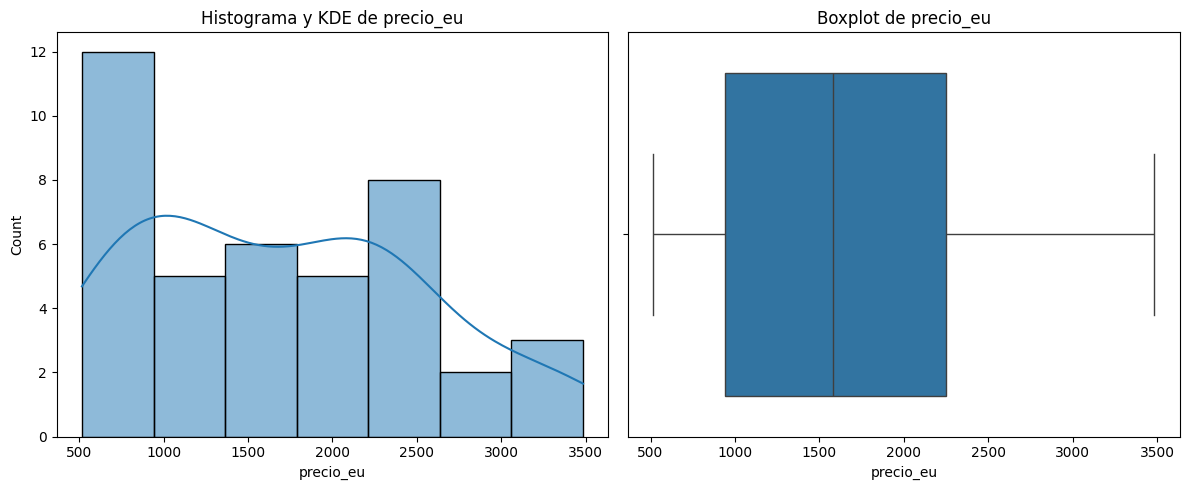

In [8]:
plot_combined_graphs(df_inm,["precio_eu"])

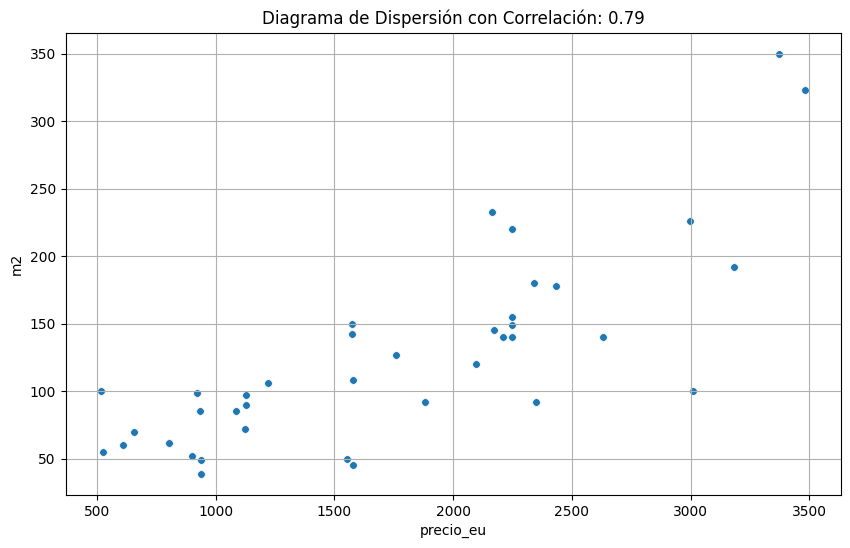

In [9]:
# Análisis bivariante
grafico_dispersion_con_correlacion(df_inm, "precio_eu","m2", mostrar_correlacion= True, tamano_puntos= 30)

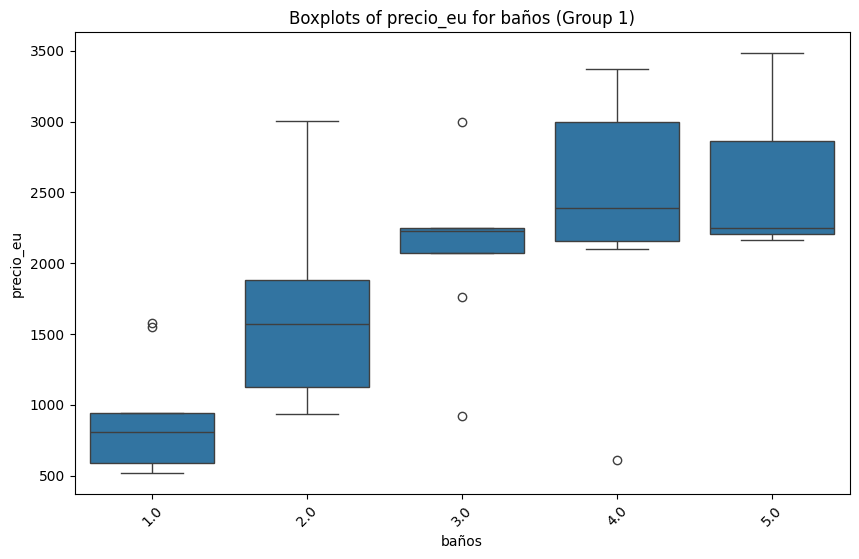

In [10]:
plot_grouped_boxplots(df_inm, "baños","precio_eu")

In [ ]:
df_inm2.head()

,titulo,precio,dormitorios,baños,m2,codigo,estacionamientos,fecha,precio_euro,precio_m2
0,"Lo Barnechea, Valle del Monasterio",2390503,5,5.0,220,26612163,2,07/03/2026,2247.07282,10865.922727
1,"Lo Barnechea, El rodeo",1673352,3,2.0,150,114822532,3,07/04/2026,1572.95088,11155.680000
2,"Lo Barnechea, Avenida San Josemaría Escrivá de...",560000,2,1.0,55,10670006,1,05/04/2026,526.40000,10181.818182
4,"Lo Barnechea, David Ben Gurion",1195252,2,2.0,72,114505801,1,04/04/2026,1123.53688,16600.722222
5,"Lo Barnechea, Av la Dehesa con Robles",996043,2,2.0,85,114428442,1,03/04/2026,936.28042,11718.152941


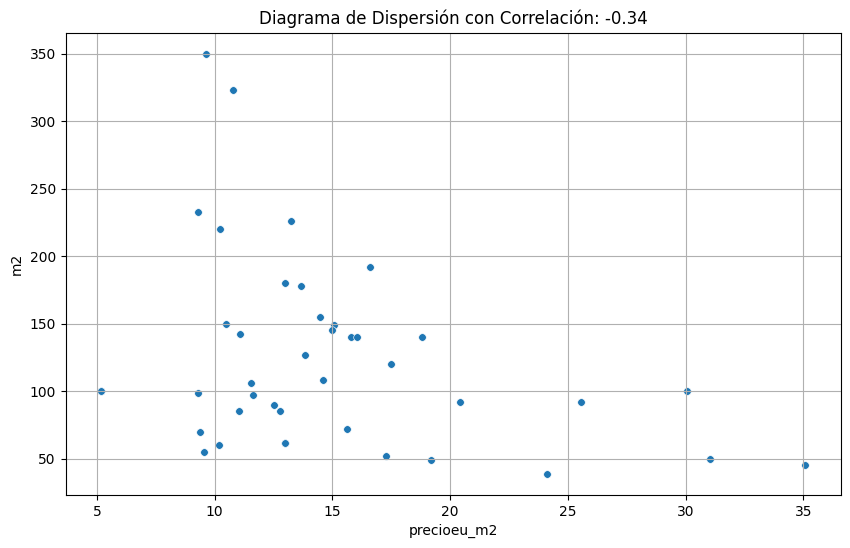

In [11]:
# Análisis bivariante

grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

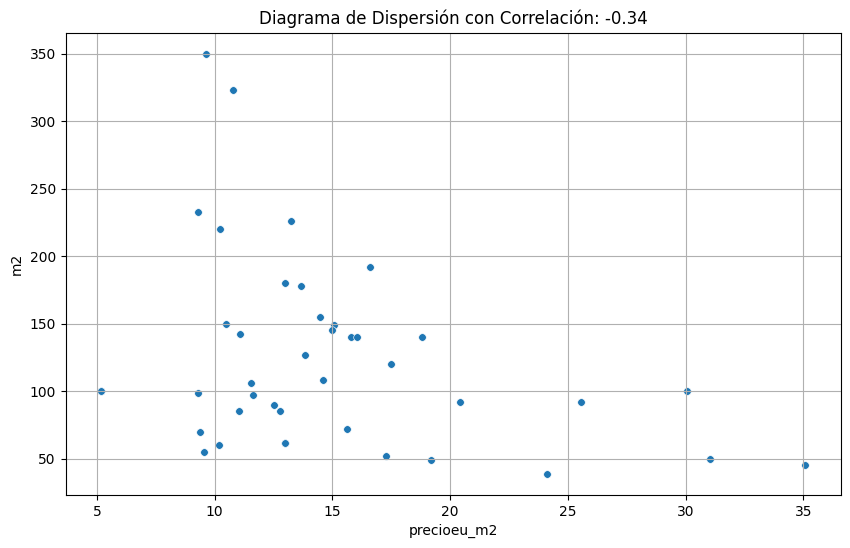

In [13]:

# Análisis bivariante

grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

In [14]:
# Análisis por grupo

rangos = [0, 40, 60, 80, 100, 120 , float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100', '100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precioeu_m2'].describe()

,count,mean,std,min,25%,50%,75%,max
grupo_m2,,,,,,,,
<40,1.0,24.102564,NaN,24.102564,24.102564,24.102564,24.102564,24.102564
40-60,6.0,20.389404,10.597253,9.570909,11.958793,18.234423,28.060918,35.093333
60-80,4.0,12.744728,2.548465,9.400000,12.090337,12.987116,13.641507,15.604679
80-100,10.0,14.366608,8.353315,5.170000,9.732554,12.085116,18.520456,30.080000
100-120,3.0,14.537169,2.975062,11.528302,13.067137,14.605972,16.041602,17.477232
>120,17.0,13.355250,2.750114,9.279220,10.783168,13.676007,15.081026,18.800000
